<a href="https://colab.research.google.com/github/sllamayo/ap155_project_euler/blob/main/Infinite_Circuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

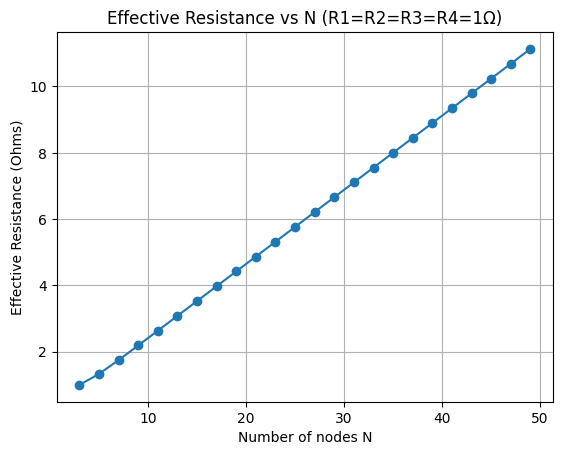

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def resistor_network(N, R1, R2, R3, R4):

    #Build conductance matrix for zigzag resistor ladder with N nodes (excluding source and ground). Returns effective resistance between V+ and ground.

    g1, g2, g3, g4 = 1/R1, 1/R2, 1/R3, 1/R4
    size = N
    G = np.zeros((size, size))

    def add_res(i, j, g):
        #Add resistor between nodes i and j with conductance g
        G[i,i] += g
        G[j,j] += g
        G[i,j] -= g
        G[j,i] -= g

    # Top rail (R1): connect even nodes
    for i in range(0, size-2, 2):
        add_res(i, i+2, g1)

    # Bottom rail (R2): connect odd nodes
    for i in range(1, size-2, 2):
        add_res(i, i+2, g2)

    # Diagonals
    for i in range(0, size-1, 2):   # odd→even (R3)
        add_res(i, i+1, g3)
    for i in range(1, size-1, 2):   # even→odd (R4)
        add_res(i, i+1, g4)

    # Boundary conditions: V0 = V+ = 1, VN-1 = 0
    Vplus, Vground = 1.0, 0.0

    G_reduced = G[1:size-1, 1:size-1]
    b = np.zeros(size-2)

    # Connection to V+
    b[0] += g1*Vplus + g3*Vplus
    # Connection to ground
    b[-1] += g2*Vground + g4*Vground

    # Solve system
    V_unknown = np.linalg.solve(G_reduced, b)
    V = np.concatenate(([Vplus], V_unknown, [Vground]))

    # Current entering at V+
    I_in = 0
    for j in range(1, size):
        if G[0,j] != 0:
            I_in += (Vplus - V[j]) * (-G[0,j])
    R_eff = Vplus / I_in
    return R_eff

# Test: equal resistors
R1 = R2 = R3 = R4 = 1.0
Nvals = range(3, 50, 2)  # must be even for symmetry
Reff = [resistor_network(N, R1, R2, R3, R4) for N in Nvals]

plt.plot(Nvals, Reff, marker='o')
plt.xlabel("Number of nodes N")
plt.ylabel("Effective Resistance (Ohms)")
plt.title("Effective Resistance vs N (R1=R2=R3=R4=1Ω)")
plt.grid(True)
plt.show()
